In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import sys

from itertools import combinations

sys.path.insert(0, "..")

### Load the data and see what minima are there

In [2]:
variance_opt_data = pd.read_csv(
    "../outputs/H4_linear_d2.5560_x0_h4_linear_2.067_perturb_all_0.txt_var_opt_data.txt",
delimiter=" ")

commutator_opt_data = pd.read_csv(
    "../outputs/H4_linear_d2.5560_x0_h4_linear_2.067_perturb_all_0.txt_comm_opt_data.txt",
delimiter=" ")

commutator_opt_data_hf = pd.read_csv(
    "../outputs/H4_linear_d2.5560_20260505_131450_comm_opt_data.txt",
delimiter=" ", skiprows=1)

In [3]:
optimized_value_indices = ["V_optimized", "Sum_CommSq_Optimized", "b_opt", "c_opt"]

Merge minima that are actually the same. Two minima are considered the same if the values of their cost functions and generalized seniority parameters $(a, b, c)$ are the same up to some tolerance. They might actually have different orbital rotations. 

In [4]:
def same_minimum(i, j, df, tol=1e-3) -> bool: 
    return np.all(np.isclose(df[optimized_value_indices].iloc[i], 
           df[optimized_value_indices].iloc[j], atol=tol))

In [5]:
variance_graph = nx.Graph()
variance_graph.add_nodes_from(range(variance_opt_data.shape[0]))
for i, j in combinations(variance_graph.nodes, 2):
    if same_minimum(i, j, variance_opt_data, tol=1e-3):
        variance_graph.add_edge(i, j)

distinct_var_minima = [min(comp) for comp in nx.connected_components(variance_graph)]
var_minima_hit_counts = [len(comp) for comp in nx.connected_components(variance_graph)]

variance_minima = variance_opt_data[optimized_value_indices].iloc[distinct_var_minima]
variance_minima["hits"] = var_minima_hit_counts
variance_minima

,V_optimized,Sum_CommSq_Optimized,b_opt,c_opt,hits
0,0.041484,0.000451,1.000011,-1.954296,13
3,0.005052,0.001709,0.999993,-1.418657,7
7,0.023559,0.001193,1.000011,-1.948301,9
14,0.081616,0.114773,0.999995,-1.933690,1


In [30]:
list(nx.connected_components(variance_graph))

[{0, 1, 2, 4, 9, 11, 15, 17, 18, 21, 25, 26, 29},
 {3, 5, 6, 19, 20, 22, 27},
 {7, 8, 10, 12, 13, 16, 23, 24, 28},
 {14}]

In [8]:
comm_graph = nx.Graph()
comm_graph.add_nodes_from(range(commutator_opt_data.shape[0]))
for i, j in combinations(comm_graph.nodes, 2):
    if same_minimum(i, j, commutator_opt_data, tol=1e-3):
        comm_graph.add_edge(i, j)

comm_var_minima = [min(comp) for comp in nx.connected_components(comm_graph)]
comm_minima_hit_counts = [len(comp) for comp in nx.connected_components(comm_graph)]

comm_minima = commutator_opt_data[optimized_value_indices].iloc[comm_var_minima]
comm_minima["hits"] = comm_minima_hit_counts
comm_minima

,V_optimized,Sum_CommSq_Optimized,b_opt,c_opt,hits
0,0.023745,0.001118,0.999997,-1.991831,10
1,0.025023,0.001919,0.999966,-1.888901,3
3,1.982571,0.000562,-1.000229,0.000083,8
6,0.045171,0.001953,1.000024,-1.936872,1
8,0.041845,0.000303,0.999473,-1.997689,3
11,0.085084,0.001314,1.000030,-1.981177,3
13,0.086349,0.001740,1.000024,-1.983794,2


In [10]:
comm_graph_hf = nx.Graph()
comm_graph_hf.add_nodes_from(range(commutator_opt_data_hf.shape[0]))
for i, j in combinations(comm_graph_hf.nodes, 2):
    if same_minimum(i, j, commutator_opt_data_hf, tol=1e-3):
        comm_graph_hf.add_edge(i, j)

comm_minima_hf = [min(comp) for comp in nx.connected_components(comm_graph_hf)]
comm_minima_hf_hit_counts = [len(comp) for comp in nx.connected_components(comm_graph_hf)]

comm_minima_hf = commutator_opt_data_hf[optimized_value_indices].iloc[comm_minima_hf]
comm_minima_hf["hits"] = comm_minima_hf_hit_counts
comm_minima_hf

,V_optimized,Sum_CommSq_Optimized,b_opt,c_opt,hits
0,0.086872,0.001489,0.998249,-1.987780,1
1,0.158918,0.004076,1.000007,-1.819580,6
2,0.086877,0.001489,1.000482,-1.990111,7
3,0.245554,0.001509,0.999896,-1.013484,5
4,0.000064,0.000731,0.999858,-1.997333,7
7,0.086873,0.001489,1.001922,-1.991542,1
13,0.158709,0.005676,1.000004,-1.821237,1
21,0.000037,0.000731,0.998463,-1.995965,1
22,0.157252,0.005104,0.999807,-1.765404,1


Printin with all the "\&" signs so that it's easy to paste into a Latex table

In [12]:
for i in range(comm_minima_hf.shape[0]):
    row = comm_minima_hf.iloc[i]
    w = ["{0:2.6f}".format(x) if type(x) == float else "{0:}".format(x)
         for x in row]
    print(" & ".join(w) + r" \\")
    # for x in row:
    #     print(x)
    # print()

0.086872 & 0.001489 & 0.998249 & -1.987780 & 1.000000 \\
0.158918 & 0.004076 & 1.000007 & -1.819580 & 6.000000 \\
0.086877 & 0.001489 & 1.000482 & -1.990111 & 7.000000 \\
0.245554 & 0.001509 & 0.999896 & -1.013484 & 5.000000 \\
0.000064 & 0.000731 & 0.999858 & -1.997333 & 7.000000 \\
0.086873 & 0.001489 & 1.001922 & -1.991542 & 1.000000 \\
0.158709 & 0.005676 & 1.000004 & -1.821237 & 1.000000 \\
0.000037 & 0.000731 & 0.998463 & -1.995965 & 1.000000 \\
0.157252 & 0.005104 & 0.999807 & -1.765404 & 1.000000 \\


See if HF-based minima and FCI-based minima agree with each other

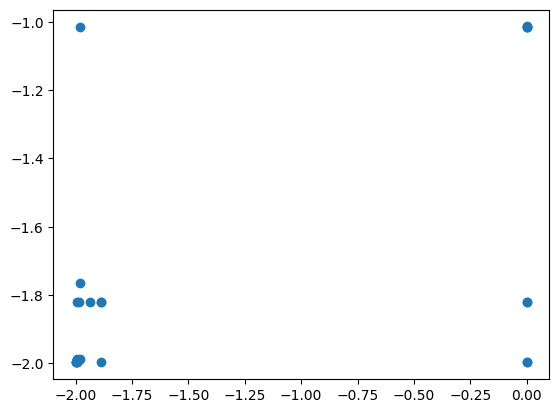

In [15]:
plt.scatter(commutator_opt_data["c_opt"], commutator_opt_data_hf["c_opt"])

#### Orbital rotations

Load the optimized parameters and construct the unitaries out of them

In [16]:
variance_opt_x = np.loadtxt(
    "../outputs/H4_linear_d2.5560_x0_h4_linear_2.067_perturb_all_0.txt_x_var_opt.txt")
commutator_opt_x = np.loadtxt(
    "../outputs/H4_linear_d2.5560_x0_h4_linear_2.067_perturb_all_0.txt_x_comm_opt.txt")
commutator_hf_opt_x = np.loadtxt(
    "../outputs/H4_linear_d2.5560_20260505_131450_x_comm_opt.txt")

In [20]:
from chemistry import build_U_from_thetas

n = 4
pairs = list(combinations(range(n), 2))
len(pairs)

6

In [21]:
Us_var = [build_U_from_thetas(n, variance_opt_x[i, :], pairs)
          for i in range(variance_opt_x.shape[0])]

Us_fci = [build_U_from_thetas(n, commutator_opt_x[i, :], pairs)
          for i in range(commutator_opt_x.shape[0])]

Us_hf = [build_U_from_thetas(n, commutator_hf_opt_x[i, :], pairs)
          for i in range(commutator_hf_opt_x.shape[0])]

The orbitals in the "same minimum" buckets are the same up to column permutations and column sign changes.

In [40]:
connected_components_var = list(nx.connected_components(variance_graph))

for i in connected_components_var[1]:
    print(variance_opt_data[optimized_value_indices].iloc[i])
    print(Us_var[i])
    print()

V_optimized             0.005052
Sum_CommSq_Optimized    0.001709
b_opt                   0.999993
c_opt                  -1.418657
Name: 3, dtype: float64
[[ 0.545273    0.54526888  0.45019849  0.45020054]
 [-0.4511204   0.45112257  0.54451039 -0.54450641]
 [-0.45019969 -0.45019934  0.5452697   0.54527218]
 [-0.54450709  0.54450971 -0.45112161  0.45112137]]

V_optimized             0.005052
Sum_CommSq_Optimized    0.001709
b_opt                   0.999998
c_opt                  -1.418717
Name: 5, dtype: float64
[[ 0.54526911  0.54526394  0.45020234 -0.45020739]
 [-0.45112778  0.45112836 -0.54450377 -0.54450213]
 [-0.45021062 -0.45019911  0.54527023 -0.54526282]
 [-0.54449585  0.54451006  0.45112512  0.45113102]]

V_optimized             0.005052
Sum_CommSq_Optimized    0.001709
b_opt                   0.999998
c_opt                  -1.418710
Name: 6, dtype: float64
[[ 0.54527178 -0.45020324 -0.54526285  0.45020457]
 [ 0.45111973 -0.54450803  0.45112934 -0.54450373]
 [-0.45020265 -0.5

In [42]:
connected_components_comm = list(nx.connected_components(comm_graph))

for i in connected_components_comm[4]:
    print(commutator_opt_data[optimized_value_indices].iloc[i])
    print(Us_fci[i])
    print()

V_optimized             0.041845
Sum_CommSq_Optimized    0.000303
b_opt                   0.999473
c_opt                  -1.997689
Name: 8, dtype: float64
[[ 0.07112897 -0.07107544 -0.70351838  0.70352743]
 [ 0.06992529  0.06984533 -0.70364265 -0.703647  ]
 [-0.70352985  0.70351595 -0.07114309  0.07106132]
 [-0.7036312  -0.70365845 -0.06991115 -0.06985947]]

V_optimized             0.041845
Sum_CommSq_Optimized    0.000303
b_opt                   0.999847
c_opt                  -1.998070
Name: 29, dtype: float64
[[ 0.07112852 -0.07115093  0.70351495 -0.70352327]
 [-0.06989418 -0.06988565 -0.70364922 -0.70363952]
 [-0.70350661  0.70353161  0.07114226 -0.0711372 ]
 [ 0.70365758  0.70363116 -0.06988046 -0.06989937]]

V_optimized             0.041845
Sum_CommSq_Optimized    0.000303
b_opt                   0.999826
c_opt                  -1.998055
Name: 21, dtype: float64
[[-0.07115436 -0.07116282  0.70352075  0.70351365]
 [ 0.06988622 -0.06991144 -0.70364163  0.70364534]
 [ 0.70353596  0

In [44]:
connected_components_comm_hf = list(nx.connected_components(comm_graph_hf))

for i in connected_components_comm_hf[7]:
    print(commutator_opt_data_hf[optimized_value_indices].iloc[i])
    print(Us_hf[i])
    print()

V_optimized             0.000037
Sum_CommSq_Optimized    0.000731
b_opt                   0.998463
c_opt                  -1.995965
Name: 21, dtype: float64
[[ 2.24235010e-03 -7.07233445e-01  7.06957796e-01 -5.14783701e-03]
 [ 5.95494876e-04 -7.06977227e-01 -7.07218971e-01  4.91660072e-03]
 [-7.06988613e-01 -1.53540322e-03  5.85603947e-03  7.07199018e-01]
 [-7.07221125e-01 -1.30278025e-03 -4.20809207e-03 -7.06978695e-01]]



So at least for the H4 chain case, the commutator measures with different references produce similar orbitals. What are these orbitals in the sense of atomic bases?

Let's get the `mo_coeff` matrix from pyscf. Its columns correspond to canonical molecular orbitals.

In [55]:
import h5py

In [56]:
hamiltonian_data = h5py.File("../hamiltonians/H4_sto-3g_singlet_H4_linear_d2.5560.hdf5",
                             "r")

In [57]:
canonical_orbitals = np.array(hamiltonian_data["canonical_orbitals"])

In [58]:
canonical_orbitals

array([[ 0.43317622, -0.53909244,  0.55974397,  0.45871166],
       [ 0.52865089, -0.44370604, -0.44734677, -0.57229539],
       [ 0.52865089,  0.44370604, -0.44734677,  0.57229539],
       [ 0.43317622,  0.53909244,  0.55974397, -0.45871166]])

The way we have it, the columns of mo_coeff times U correspond to new orbitals in the atomic orbital basis.

The variance search effectively tries to undo the Hartree--Fock process and get back to atomic orbitals:

In [63]:
print(canonical_orbitals @ Us_var[3])

print()
print(canonical_orbitals @ Us_var[np.argmin(variance_opt_data["V_optimized"])])

[[-2.23734182e-02 -9.22267477e-03 -2.49473019e-04  1.00070291e+00]
 [ 1.00143818e+00 -2.21341089e-02  1.06454627e-02 -2.25007263e-02]
 [-2.21293131e-02  1.00143831e+00 -2.24990728e-02  1.06470623e-02]
 [-9.22111865e-03 -2.23750374e-02  1.00070289e+00 -2.44935058e-04]]

[[-9.23407075e-03 -1.00070277e+00  2.23748036e-02  2.47415430e-04]
 [-2.21318976e-02  2.24995947e-02 -1.00143813e+00 -1.06573641e-02]
 [ 1.00143813e+00 -1.06584440e-02  2.21310096e-02  2.24999034e-02]
 [-2.23744616e-02  2.47520763e-04  9.23300644e-03 -1.00070279e+00]]


FCI-based commutator optimization finds bonding and antibonding orbitals of the first two and second two hydrogen atoms:

In [64]:
print(canonical_orbitals @ Us_fci[8])

print()
print(canonical_orbitals @ Us_fci[np.argmin(commutator_opt_data["Sum_CommSq_Optimized"])])

[[-0.72344525  0.0025712   0.00269002  0.69181293]
 [ 0.72398282  0.01942     0.01213034  0.69232402]
 [-0.01933441 -0.72399938 -0.69231031 -0.01206133]
 [-0.00252518  0.72343005 -0.69182873 -0.00275793]]

[[-0.00251704  0.72341533  0.69184439  0.00269492]
 [-0.01937395 -0.72401278  0.69229421  0.01211698]
 [ 0.72400108  0.01933958 -0.01211713 -0.6923074 ]
 [-0.72342776  0.00253805 -0.0027096  -0.69183126]]


HF-based optimization does the same thing:

In [65]:
print(canonical_orbitals @ Us_hf[21])

print()
print(canonical_orbitals @ Us_hf[np.argmin(commutator_opt_data_hf["Sum_CommSq_Optimized"])])

[[-0.71949288  0.07331234  0.68884129  0.0666706 ]
 [ 0.72192966 -0.05875709  0.68731979  0.08333452]
 [-0.08702067 -0.68762837  0.05490859 -0.72150373]
 [-0.07002968 -0.68774462 -0.06981091  0.72057034]]

[[ 0.68811897 -0.06668716 -0.06987335  0.72052399]
 [ 0.6880139  -0.08356848  0.05506862 -0.72153211]
 [ 0.05507993  0.72153039  0.68801556  0.08356217]
 [-0.06988486 -0.72052362  0.68811968  0.0666717 ]]


#### Cross-check of the optimized parameters

The orbitals look close, but does it translate to the costs being similar?

In [113]:
import openfermion as of
import scipy.sparse.linalg as spla

from optimization_different_abc import popcount, compute_spin_rdms_from_statevector
from optimize_for_commutator import commutator_cost_function_fixed_abc, commutator_cost_number_pres
from optimization_abc import variance_restricted

In [84]:
mol = of.MolecularData(filename="../hamiltonians/H4_sto-3g_singlet_H4_linear_d2.5560.hdf5")

In [157]:
H_ferm = of.get_fermion_operator(
        mol.get_molecular_hamiltonian())
H_qubit = of.jordan_wigner(H_ferm)
H_full = of.get_sparse_operator(H_qubit, 2 * mol.n_orbitals).tocsc()

basis_bitstrings = [b for b in range(2**(2 * mol.n_orbitals))
                    if popcount(b) == mol.n_electrons]
basis_idx = np.array(basis_bitstrings, dtype=int)

H_sub = H_full[basis_idx, :][:, basis_idx].tocsc()
evals, evecs = spla.eigsh(H_sub, k=1, which="SA")
E_fci = float(np.real(evals[0]))
v_sub = evecs[:, 0]

psi_full = np.zeros(2**(2 * mol.n_orbitals), dtype=np.complex128)
psi_full[basis_idx] = v_sub
psi_full /= np.linalg.norm(psi_full)

H_number = of.get_number_preserving_sparse_operator(
        H_ferm, num_electrons=mol.n_electrons,
        num_qubits=mol.n_orbitals * 2
    ).todense()

psi_hf = np.zeros(H_number.shape[0])
psi_hf[0] = 1.
psi_hf_sub = np.zeros_like(psi_hf)
psi_hf_sub[-1] = 1.
psi_hf_full = np.zeros(2**(2 * mol.n_orbitals), dtype=np.complex128)
psi_hf_full[basis_idx] = psi_hf_sub

_, psi_fci_number = spla.eigsh(H_number, which="SA", k=1)


In [158]:
psi_hf @ H_number @ psi_hf

matrix([[-1.39602594]])

In [159]:
mol.hf_energy

array(-1.39602594)

In [160]:
psi_hf_full @ H_full @ psi_hf_full

(-1.396025935785256+0j)

In [161]:
np.diag(H_sub.todense())

array([-1.1819699 +0.j, -1.32689756+0.j, -1.17839128+0.j, -1.33582036+0.j,
       -1.18970519+0.j, -1.17839128+0.j, -1.32689756+0.j, -1.18970519+0.j,
       -1.33582036+0.j, -1.17398244+0.j, -1.36716272+0.j, -1.18618346+0.j,
       -1.18618346+0.j, -1.36716272+0.j, -1.17088627+0.j, -1.32846769+0.j,
       -1.18553111+0.j, -1.36290393+0.j, -1.22813847+0.j, -1.3548431 +0.j,
       -1.86258857+0.j, -1.40072868+0.j, -1.39016646+0.j, -1.29026508+0.j,
       -1.40855382+0.j, -1.18075224+0.j, -1.39387626+0.j, -1.22424671+0.j,
       -1.2184667 +0.j, -1.41079566+0.j, -1.23446295+0.j, -1.42030856+0.j,
       -1.2855431 +0.j, -1.43958304+0.j, -1.29664646+0.j, -1.18553111+0.j,
       -1.32846769+0.j, -1.22813847+0.j, -1.36290393+0.j, -1.18075224+0.j,
       -1.41079566+0.j, -1.2184667 +0.j, -1.22424671+0.j, -1.39387626+0.j,
       -1.23446295+0.j, -1.3548431 +0.j, -1.29026508+0.j, -1.39016646+0.j,
       -1.40072868+0.j, -1.86258857+0.j, -1.40855382+0.j, -1.2855431 +0.j,
       -1.42030856+0.j, -

In [190]:
np.diag(H_number) - np.diag(H_sub.todense())[::-1]

array([-1.55431223e-15+0.j,  1.86902498e-01+0.j, -1.04540357e-01+0.j,
        1.53217938e-01+0.j, -1.27662691e-01+0.j, -1.04540357e-01+0.j,
        1.86902498e-01+0.j, -1.27662691e-01+0.j,  1.53217938e-01+0.j,
       -6.18134705e-02+0.j, -7.08501838e-02+0.j, -6.09263583e-02+0.j,
       -2.07041526e-01+0.j, -7.08501838e-02+0.j, -1.72331080e-01+0.j,
        8.21998279e-04+0.j,  4.00058586e-03+0.j,  2.49422300e-01+0.j,
       -8.16196166e-02+0.j,  2.22370357e-01+0.j,  6.76405107e-01+0.j,
        3.35659611e-02+0.j,  2.16184012e-01+0.j, -1.18288734e-01+0.j,
        6.45780181e-02+0.j, -1.55703503e-01+0.j, -6.85242149e-03+0.j,
       -6.38341860e-01+0.j, -1.36376408e-01+0.j,  1.76332709e-01+0.j,
       -2.30043424e-01+0.j,  1.44437237e-01+0.j,  3.89176313e-03+0.j,
       -6.54085676e-02+0.j,  4.77887537e-03+0.j,  6.21835076e-02+0.j,
        4.57067803e-02+0.j,  6.12963953e-02+0.j,  2.01841869e-01+0.j,
       -1.76332709e-01+0.j,  2.30043424e-01+0.j, -1.90087123e-01+0.j,
       -6.38341860e-

In [163]:
psi_full.conj() @ H_full @ psi_full

(-1.8711680598733078+6.938893903907228e-18j)

In [164]:
evals

array([-1.87116806])

In [165]:
psi_fci_number[:, 0] @ H_number @ psi_fci_number[:, 0]

matrix([[-1.87116806]])

In [166]:
v_sub.conj() @ H_number @ v_sub

matrix([[-1.34193992+0.j]])

In [167]:
v_sub.conj() @ H_sub @ v_sub

(-1.8711680598733094+0j)

In [168]:
commutator_cost_fci = commutator_cost_function_fixed_abc(H_full, psi_full)

commutator_cost_hf = commutator_cost_function_fixed_abc(H_full, psi_hf_full)

commutator_cost_hf_number = commutator_cost_number_pres(
    H_number, psi_hf, mol.n_electrons, mol.n_orbitals)[0]

commutator_cost_fci_number = commutator_cost_number_pres(
    H_number, psi_fci_number, mol.n_electrons, mol.n_orbitals)[0]

In [169]:
rdms_fci = compute_spin_rdms_from_statevector(psi_full, mol.n_orbitals)
rdms_hf = compute_spin_rdms_from_statevector(psi_hf_full, mol.n_orbitals)

variance_cost_fci = lambda x: variance_restricted(
    rdms_fci[0], rdms_fci[1], rdms_fci[2], x, pairs
)[0]

variance_cost_hf = lambda x: variance_restricted(
    rdms_hf[0], rdms_hf[1], rdms_hf[2], x, pairs
)[0]

In [170]:
best_var_point = np.argmin(variance_opt_data["V_optimized"])
best_comm_fci_point = np.argmin(commutator_opt_data["Sum_CommSq_Optimized"])
best_comm_hf_point = np.argmin(commutator_opt_data_hf["Sum_CommSq_Optimized"])

best_var_x = variance_opt_x[best_var_point, :]
best_comm_fci_x = commutator_opt_x[best_comm_fci_point, :]
best_comm_hf_x = commutator_hf_opt_x[best_comm_hf_point, :]

In [171]:
commutator_opt_data_hf.iloc[best_comm_hf_point]

E_FCI                  -1.871168
V_0                     0.520950
V_optimized             0.000064
Sum_CommSq_0            0.249891
Sum_CommSq_Optimized    0.000731
a_opt                   1.000000
b_opt                   0.999858
c_opt                  -1.997333
Name: 4, dtype: float64

The minimum for the HF commutator cost yields a noticeably larger cost when evaluated against the FCI function, even larger than the minimum for the variance-based FCI; still, these are all small values compared to a generic point.

In [172]:
commutator_cost_hf(best_comm_fci_x)

0.0010385699997719424

In [173]:
commutator_cost_hf_number(best_comm_fci_x)

0.001038569999771942

In [174]:
print(commutator_cost_fci(best_var_x))
print(commutator_cost_fci(best_comm_fci_x))
print(commutator_cost_fci(best_comm_hf_x))
print(commutator_cost_fci(np.ones(best_var_x.shape[0])))

0.0017089115846145046
0.0003025998260230095
0.0034087928727811055
0.6630382355541069


In [175]:
print(commutator_cost_fci_number(best_var_x))
print(commutator_cost_fci_number(best_comm_fci_x))
print(commutator_cost_fci_number(best_comm_hf_x))
print(commutator_cost_fci_number(np.ones(best_var_x.shape[0])))

0.0017089115846144875
0.00030259982602303824
0.003408814603946496
0.6630382355541251


HF-based commutator cost is less sensitive and yields similar counts for both the FCI-optimized and HF-optimized parameters

In [176]:
print(commutator_cost_hf(best_var_x))
print(commutator_cost_hf(best_comm_fci_x))
print(commutator_cost_hf(best_comm_hf_x))
print(commutator_cost_hf(np.ones(best_var_x.shape[0])))

0.0016458888930793811
0.0010385699997719424
0.0007305314365304665
0.49286876476186203


In [177]:
print(commutator_cost_hf_number(best_var_x))
print(commutator_cost_hf_number(best_comm_fci_x))
print(commutator_cost_hf_number(best_comm_hf_x))
print(commutator_cost_hf_number(np.ones(best_var_x.shape[0])))

0.0016458888930793725
0.001038569999771942
0.0007305314035508416
0.4928687647618619


In [178]:
print(variance_cost_fci(best_var_x))
print(variance_cost_fci(best_comm_fci_x))
print(variance_cost_fci(best_comm_hf_x))
print(variance_cost_fci(np.ones(best_var_x.shape[0])))

0.0050517658213631855
0.04184504825801366
0.04460629626371306
1.736257281019176


In [179]:
print(variance_cost_hf(best_var_x))
print(variance_cost_hf(best_comm_fci_x))
print(variance_cost_hf(best_comm_hf_x))
print(variance_cost_hf(np.ones(best_var_x.shape[0])))

0.16749710044809246
0.01286256655769144
6.42613962007778e-05
0.8520740043769113


In [185]:
comm_minima_hf

,V_optimized,Sum_CommSq_Optimized,b_opt,c_opt,hits
0,0.086872,0.001489,0.998249,-1.987780,1
1,0.158918,0.004076,1.000007,-1.819580,6
2,0.086877,0.001489,1.000482,-1.990111,7
3,0.245554,0.001509,0.999896,-1.013484,5
4,0.000064,0.000731,0.999858,-1.997333,7
7,0.086873,0.001489,1.001922,-1.991542,1
13,0.158709,0.005676,1.000004,-1.821237,1
21,0.000037,0.000731,0.998463,-1.995965,1
22,0.157252,0.005104,0.999807,-1.765404,1


In [189]:
for i in [min(comp) for comp in nx.connected_components(comm_graph_hf)]:
    print("{0:0.6f}".format(variance_cost_hf(commutator_hf_opt_x[i, :])))

0.086874
0.158918
0.086879
0.245554
0.000064
0.086874
0.158720
0.000037
0.157251
